In [1]:
from google.colab import files, drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

import json
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import random
import string
import re
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [3]:
abstract_train2015 = pd.read_csv("/content/drive/MyDrive/VQA_Dataset/abstract_train2015_preprocessed.csv")
print('Number of Question & Answer in Train Dataset:',len(abstract_train2015))

Number of Question & Answer in Train Dataset: 60000


In [4]:
abstract_train2015

,image_id,question_id,question_preprocessed,question_type,answer_preprocessed,answers,answer_type
0,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,117792,who looks happier,who,man,"['old person', 'man', 'man', 'man', 'old man',...",other
1,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,117790,where is the woman sitting,where is the,blanket,"['on blanket', 'blanket', 'on blanket', 'blank...",other
2,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,117791,where is the man sitting,where is the,bench,"['on bench', 'bench', 'on bench', 'bench', 'be...",other
3,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,55360,is this man hungry,is this,yes,"['yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'ye...",yes/no
4,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,55361,what kind of drink is that,what kind of,soda,"['water', 'soda', 'wine', 'soft', 'soda', 'sod...",other
...,...,...,...,...,...,...,...
59995,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,116950,what color is the log the little girl sitting on,what color is the,brown,"['brown', 'brown', 'brown', 'brown', 'brown', ...",other
59996,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,116951,does the boy want to go on the seesaw,does the,yes,"['yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'ye...",yes/no
59997,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,137900,what animal is between the two men,what animal is,cat,"['cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'ca...",other
59998,/content/drive/MyDrive/VQA_Dataset/scene_img_a...,137901,what food is by the picnic basket,what,watermelon,"['watermelon, sandwich, burger', 'watermelon',...",other


In [5]:
image_path = list(abstract_train2015['image_id'])
question_preprocessed = list(abstract_train2015['question_preprocessed'])
answer_preprocessed = list(abstract_train2015['answer_preprocessed'])
question_type = list(abstract_train2015['question_type'])
answer_type = list(abstract_train2015['answer_type'])

In [6]:
print(f"Total unique images: {len(set(image_path))}")
print(f"Total unique questions: {len(set(question_preprocessed))}")
print(f"Total unique answers: {len(set(answer_preprocessed))}")
print(f"Total unique question types: {len(set(question_type))}")
print(f"Total unique answer types: {len(set(answer_type))}")


Total unique images: 20000
Total unique questions: 34688
Total unique answers: 2508
Total unique question types: 81
Total unique answer types: 3


In [7]:
image_path[0]

'/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_train2015/abstract_v002_train2015_000000011779.png'

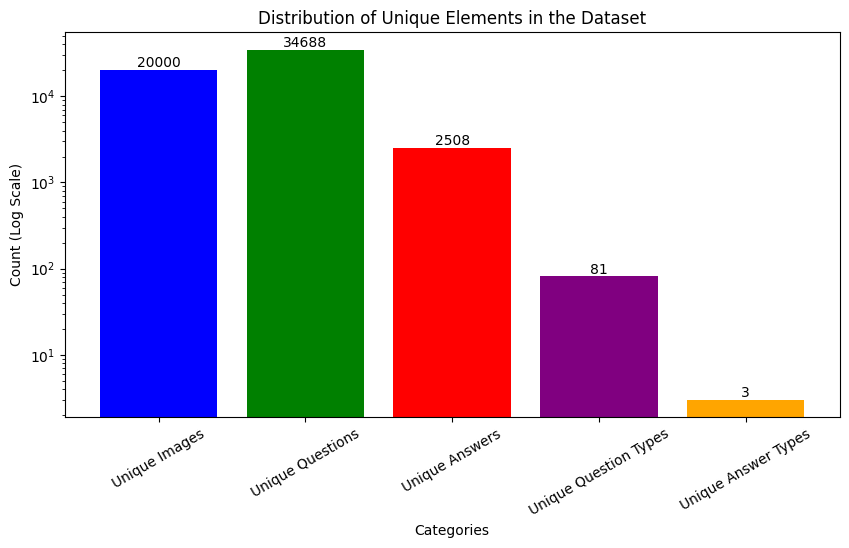

In [8]:
import matplotlib.pyplot as plt

# Data for plotting
categories = ["Unique Images", "Unique Questions", "Unique Answers", "Unique Question Types", "Unique Answer Types"]
values = [20000, 34688, 2508, 81, 3]

# Create bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(categories, values, color=['blue', 'green', 'red', 'purple', 'orange'])

# Adjust y-axis to log scale for better visibility
plt.yscale('log')

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, str(yval), ha='center', va='bottom', fontsize=10)

# Labels and title
plt.xlabel("Categories")
plt.ylabel("Count (Log Scale)")
plt.title("Distribution of Unique Elements in the Dataset")
plt.xticks(rotation=30)

# Show plot
plt.show()


In [ ]:
df['question_preprocessed'].apply(lambda x: len(x.split())).hist()

NameError: name 'df' is not defined

In [ ]:
df = abstract_train2015

# EDA - IMAGE

In [ ]:
# # Calculate image shape
# image_shape = []
# for i in tqdm(range(len(abstract_train2015))):
#     image = cv2.imread(image_path[i])
#     image_shape.append(image.shape)

In [ ]:
# import pickle

# # Save to pickle
# with open("image_shapes.pkl", "wb") as f:
#     pickle.dump(image_shape, f)

In [ ]:
import pickle

# Load the pickle file
with open("image_shapes.pkl", "rb") as f:
    image_shape = pickle.load(f)

# Check the first few entries
print(image_shape[:5])  # Display first 5 image shapes


[(400, 700, 3), (400, 700, 3), (400, 700, 3), (400, 700, 3), (400, 700, 3)]


In [ ]:
height = list((list(zip(*image_shape)))[0])
width = list((list(zip(*image_shape)))[1])
channel = list((list(zip(*image_shape)))[2])

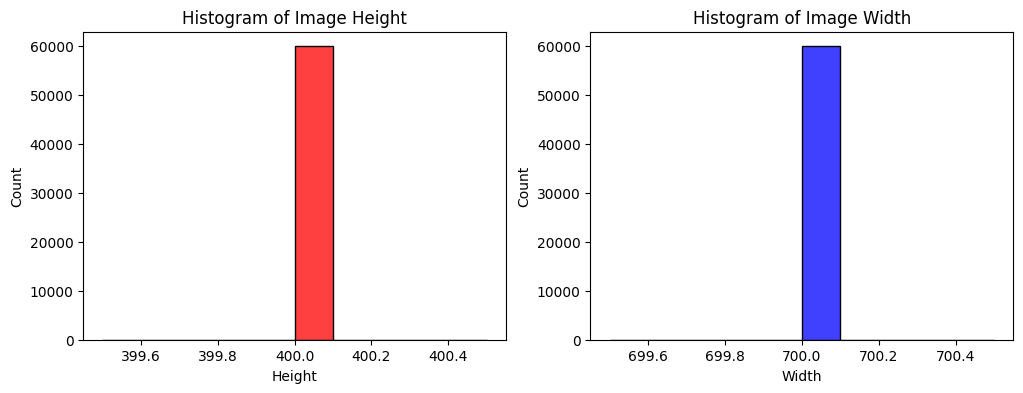

In [ ]:
# Histogram of Image Height and width

plt.figure(figsize=(12, 4))

# Histogram for Height
plt.subplot(1, 2, 1)
sns.histplot(height, bins=10, kde=False, color="red")
plt.title("Histogram of Image Height")
plt.xlabel("Height")

# Histogram for Width
plt.subplot(1, 2, 2)
sns.histplot(width, bins=10, kde=False, color="blue")
plt.title("Histogram of Image Width")
plt.xlabel("Width")

plt.show()


In [ ]:
print(f"Maximum Height: {max(height)}  Maximum Width: {max(width)}")
print(f"Minimum Height: {min(height)}  Minimum Width: {min(width)}")
print(f"Mean Height: {np.round(np.mean(height),2)}  Mean Width: {np.round(np.mean(width),2)}")
print(f"All the Images have same channel depth of {list(set(channel))[0]}.")

Maximum Height: 400  Maximum Width: 700
Minimum Height: 400  Minimum Width: 700
Mean Height: 400.0  Mean Width: 700.0
All the Images have same channel depth of 3.


Max number of questions on an image: 3
Min number of questions on an image: 3
Mean number of questions per image: 3.0


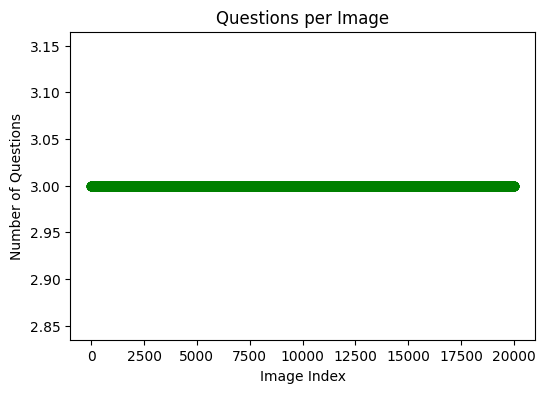

In [ ]:
# Questions per Image


# Create DataFrame
df = pd.DataFrame({
    'image_path': image_path,
    'question': question_preprocessed,
    'answer': answer_preprocessed,
    'question_type': question_type,
    'answer_type': answer_type
})

# Extract image_id from the image path
df['image_id'] = df['image_path'].apply(lambda x: x.split('/')[-1])  # Extract filename

# Count questions per image
aggregations = {'question': 'count'}
temp = df.groupby('image_id', as_index=False).agg(aggregations)

# Get stats
num_of_ques_in_image = temp['question'].values
print("Max number of questions on an image:", max(num_of_ques_in_image))
print("Min number of questions on an image:", min(num_of_ques_in_image))
print("Mean number of questions per image:", np.mean(num_of_ques_in_image))

plt.figure(figsize=(6, 4))
plt.scatter(range(len(num_of_ques_in_image)), num_of_ques_in_image, alpha=0.5, color="green")
plt.title("Questions per Image")
plt.xlabel("Image Index")
plt.ylabel("Number of Questions")
plt.show()



# EDA - QUESTION

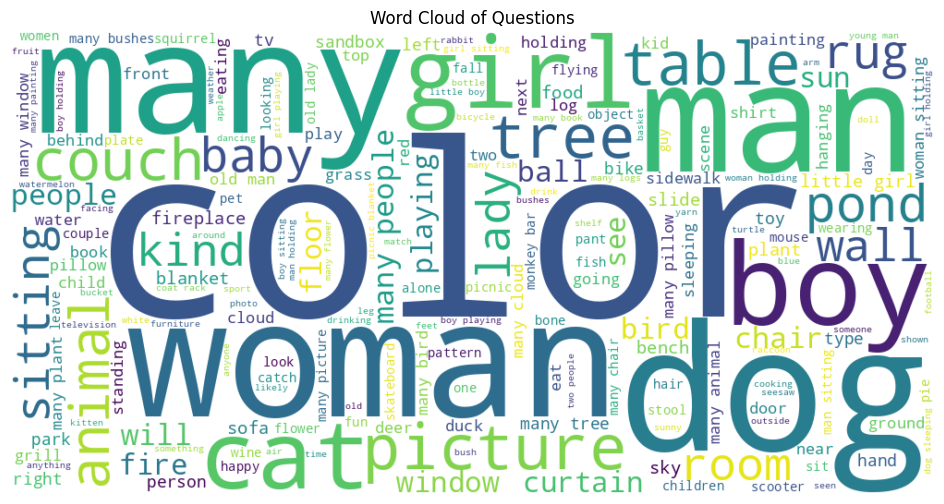

In [ ]:
# most frequently occurring words

from wordcloud import WordCloud

question_text = " ".join(question_preprocessed)  # Combine all questions
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(question_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Questions")
plt.show()


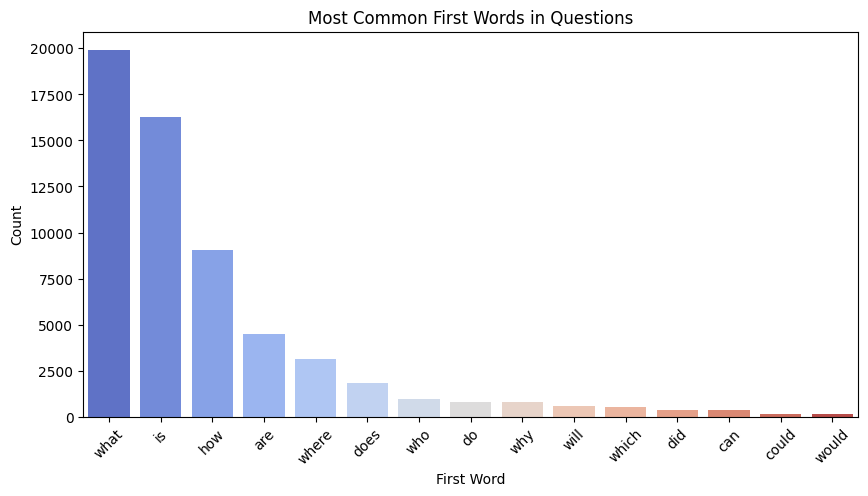

In [ ]:
# Most Common First Words in Questions

first_words = [q.split()[0] for q in question_preprocessed]
first_word_counts = pd.Series(first_words).value_counts().head(15)  # Top 15 first words

plt.figure(figsize=(10, 5))
sns.barplot(x=first_word_counts.index, y=first_word_counts.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Most Common First Words in Questions")
plt.xlabel("First Word")
plt.ylabel("Count")
plt.show()


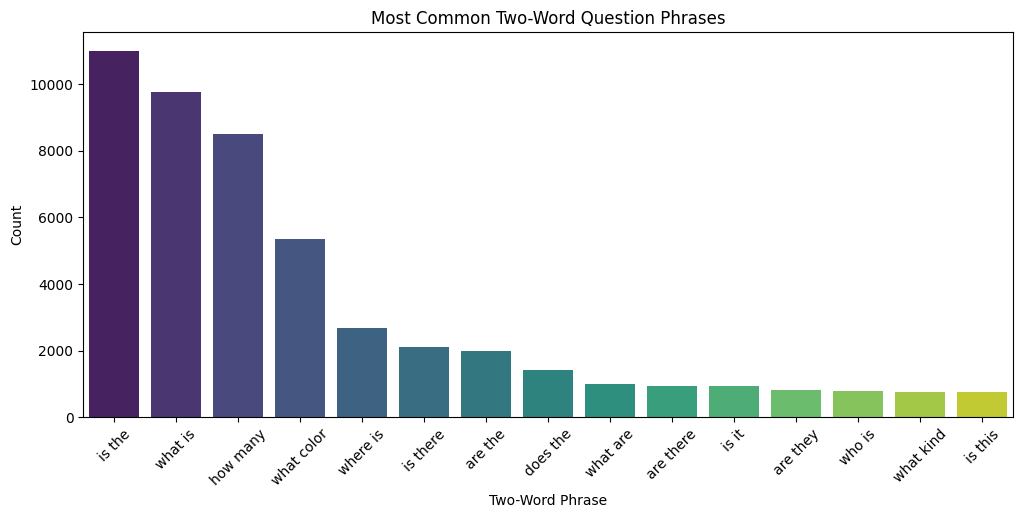

In [ ]:
two_word_phrases = [" ".join(q.split()[:2]) for q in question_preprocessed]
two_word_counts = pd.Series(two_word_phrases).value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=two_word_counts.index, y=two_word_counts.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Most Common Two-Word Question Phrases")
plt.xlabel("Two-Word Phrase")
plt.ylabel("Count")
plt.show()


In [ ]:
# Create list of Character count, Word count, First one word, First two words, and unique words of questions
char_count_que = []
word_count_que = []
first_word_que = []
two_word_que = []
unique_word_que = []

for q in question_preprocessed:
    char_count_que.append(len(q))
    word_count_que.append(len(q.split()))
    first_word_que.append(q.split()[0].lower())
    two_word_que.append(" ".join(q.split()[:2]).lower())
    unique_word_que.extend(q.split())
unique_word_que = set(unique_word_que)

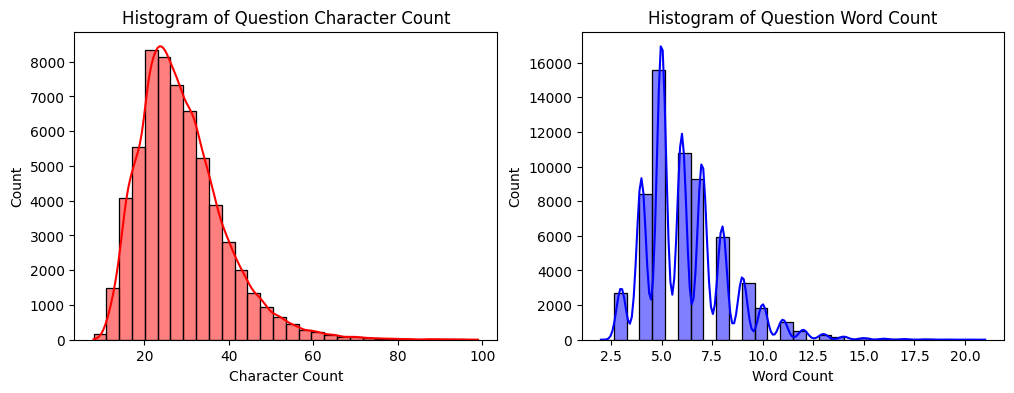

In [ ]:
plt.figure(figsize=(12, 4))

# Histogram for Character Count
plt.subplot(1, 2, 1)
sns.histplot(char_count_que, bins=30, kde=True, color="red")
plt.title("Histogram of Question Character Count")
plt.xlabel("Character Count")

# Histogram for Word Count
plt.subplot(1, 2, 2)
sns.histplot(word_count_que, bins=30, kde=True, color="blue")
plt.title("Histogram of Question Word Count")
plt.xlabel("Word Count")

plt.show()


In [ ]:
# Percentile of word_count_que
for i in range(0,101,10):
    print(f"{i}th percentile {np.percentile(word_count_que,i)}")
print("-"*25)
for i in range(91,101,1):
    print(f"{i}th percentile {np.percentile(word_count_que,i)}")

0th percentile 2.0
10th percentile 4.0
20th percentile 5.0
30th percentile 5.0
40th percentile 5.0
50th percentile 6.0
60th percentile 6.0
70th percentile 7.0
80th percentile 8.0
90th percentile 9.0
100th percentile 21.0
-------------------------
91th percentile 9.0
92th percentile 9.0
93th percentile 9.0
94th percentile 10.0
95th percentile 10.0
96th percentile 10.0
97th percentile 11.0
98th percentile 11.0
99th percentile 13.0
100th percentile 21.0


In [ ]:
print("The maximum character length of Question:", max(char_count_que))
print("The minimum character length of Question:", min(char_count_que))
print('The average character length of Question:',int(sum(char_count_que)/len(char_count_que)))
print('-'*50)
print("The maximum word length of Question:", max(word_count_que))
print("The minimum word length of Question:", min(word_count_que))
print('The average word length of Question:',int(sum(word_count_que)/len(word_count_que)))
print('-'*50)
print('Total unique words in questions:',len(unique_word_que))

The maximum character length of Question: 99
The minimum character length of Question: 8
The average character length of Question: 28
--------------------------------------------------
The maximum word length of Question: 21
The minimum word length of Question: 2
The average word length of Question: 6
--------------------------------------------------
Total unique words in questions: 4511


In [ ]:
print('Types of questions as per given question_type:',len(set(question_type)))
print('Types of questions as per first one word of question:',len(set(first_word_que)))
print('Types of questions as per first two word of question:',len(set(two_word_que)))

Types of questions as per given question_type: 81
Types of questions as per first one word of question: 80
Types of questions as per first two word of question: 1068


In [ ]:
# Create dataframe of First one word of question and its question count
count = {}
for i in first_word_que:
    count[i] = count.get(i, 0) + 1

first_word_que_df = pd.DataFrame(list(count.items()),columns=["first_word","question_count"])
first_word_que_df["question_%"] = first_word_que_df["question_count"]/len(first_word_que)*100
first_word_que_df = first_word_que_df.sort_values(by='question_count',ascending=False)
first_word_que_df.head(5)

,first_word,question_count,question_%
3,what,19909,33.181667
2,is,16276,27.126667
4,how,9026,15.043333
7,are,4480,7.466667
1,where,3139,5.231667


In [ ]:
# Create dataframe of First two words of question and its question count
count = {}
for i in two_word_que:
    count[i] = count.get(i, 0) + 1

two_word_que_df = pd.DataFrame(list(count.items()),columns=["two_word","question_count"])
two_word_que_df["question_%"] = two_word_que_df["question_count"]/len(first_word_que)*100
two_word_que_df = two_word_que_df.sort_values(by='question_count',ascending=False)
two_word_que_df.head(10)

,two_word,question_count,question_%
11,is the,11010,18.350000
8,what is,9761,16.268333
15,how many,8493,14.155000
4,what color,5356,8.926667
1,where is,2687,4.478333
16,is there,2113,3.521667
23,are the,1998,3.330000
21,does the,1406,2.343333
24,what are,992,1.653333
30,are there,934,1.556667


# EDA - ANSWER

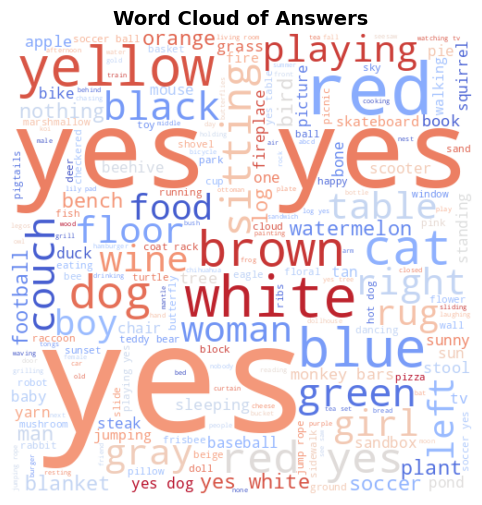

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all answers into a single string
answer_text = " ".join(answer_preprocessed)

# Generate the word cloud
wordcloud = WordCloud(width=500, height=500, background_color="white", colormap="coolwarm").generate(answer_text)

# Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Answers", fontsize=14, fontweight="bold")
plt.show()


## Chat GPT code for Word Cloud on1 April

In [ ]:
from collections import Counter

# Count frequency
answer_counts = Counter(flattened_answers)
print(answer_counts['no'])  # How often "no" appears

10143


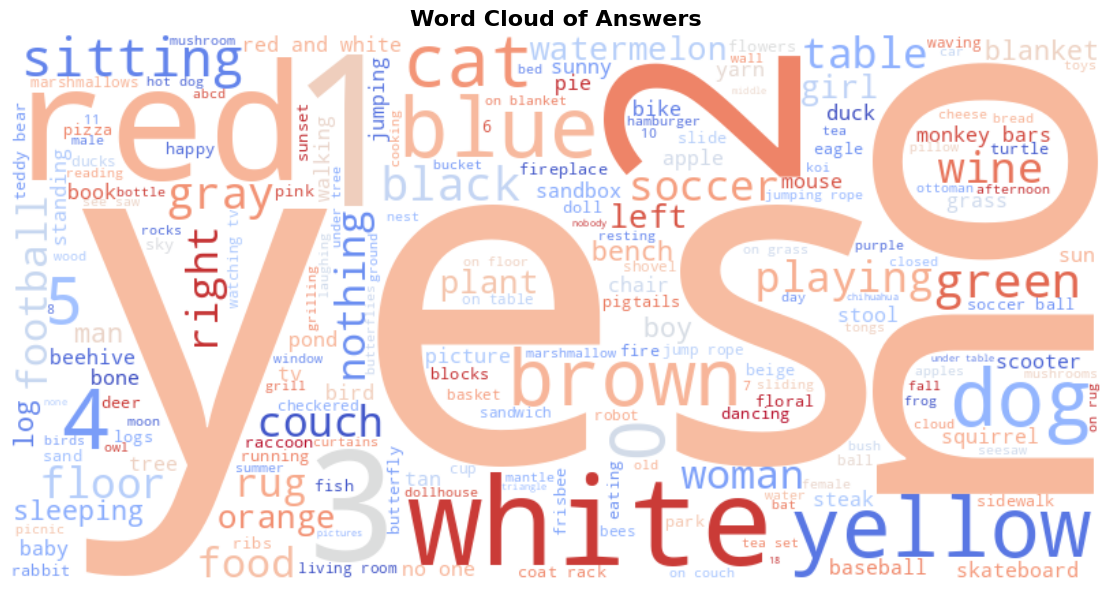

In [ ]:
from collections import Counter

# Count word frequencies
answer_counts = Counter([ans.lower().strip() for ans in flattened_answers])

# Generate word cloud from frequencies
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="coolwarm",
    collocations=False
).generate_from_frequencies(answer_counts)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Answers", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
answer_lengths = [len(a.split()) for a in answer_preprocessed]
# Count of single-word answers
one_word_count = sum(1 for l in answer_lengths if l == 1)
print(f"Number of answers with exactly 1 word: {one_word_count}")

Number of answers with exactly 1 word: 56098


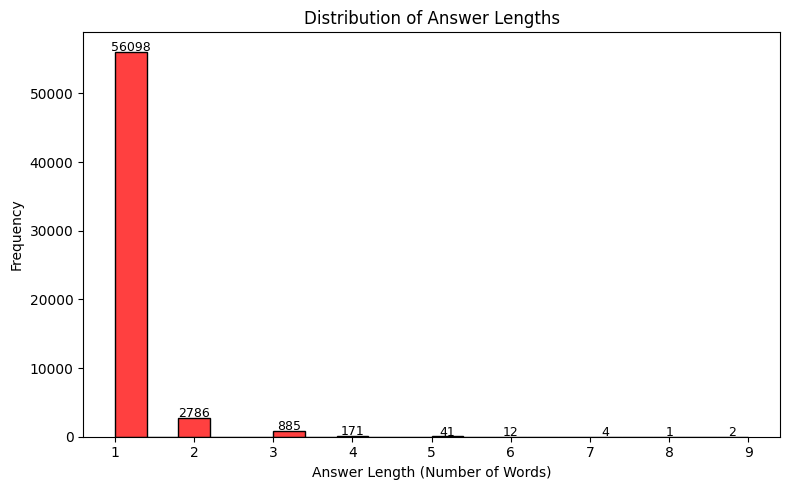

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate answer lengths
answer_lengths = [len(a.split()) for a in answer_preprocessed]

# Plot and capture the histogram
plt.figure(figsize=(8, 5))
ax = sns.histplot(answer_lengths, bins=20, color="red")

# Add count labels on top of each bar
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        ax.text(patch.get_x() + patch.get_width()/2, height + 100,  # 100 is a vertical buffer
                f"{int(height)}", ha="center", fontsize=9, color="black")

# Labels and title
plt.xlabel("Answer Length (Number of Words)")
plt.ylabel("Frequency")
plt.title("Distribution of Answer Lengths")
plt.tight_layout()
plt.show()


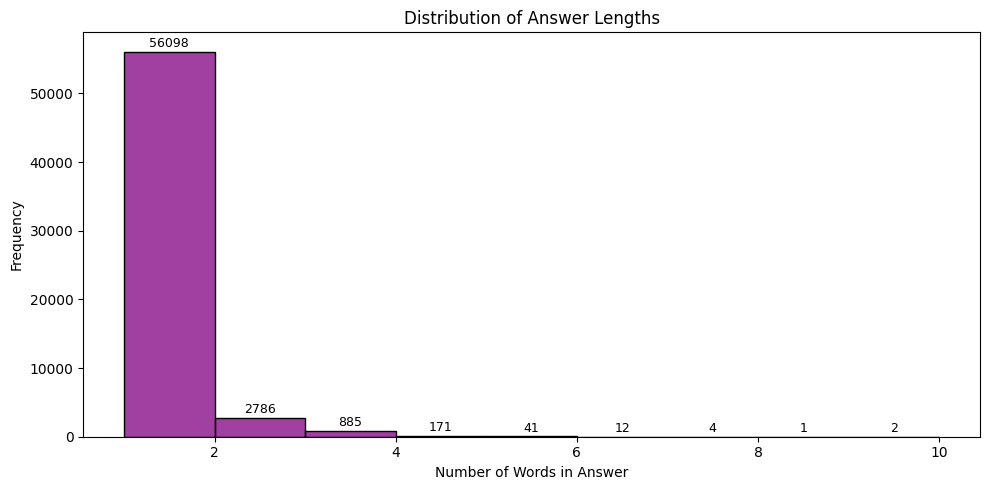

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute lengths
answer_lengths = [len(a.split()) for a in answer_preprocessed]

# Set up plot
plt.figure(figsize=(10, 5))
ax = sns.histplot(answer_lengths, bins=range(1, max(answer_lengths)+2), kde=False, color="purple")

# Add count labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 200,  # adjust to avoid overlapping bars
            f'{int(height)}',
            ha="center",
            va="bottom",
            fontsize=9
        )

# Add titles and labels
plt.title("Distribution of Answer Lengths")
plt.xlabel("Number of Words in Answer")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


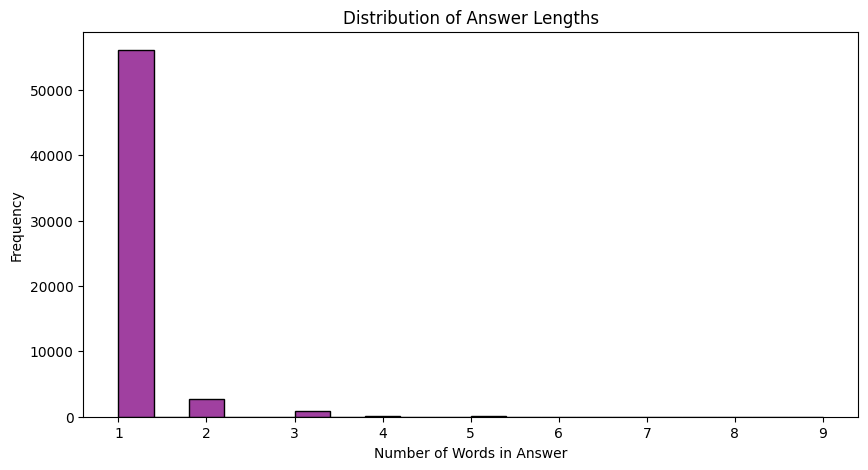

In [ ]:
answer_lengths = [len(a.split()) for a in answer_preprocessed]

plt.figure(figsize=(10, 5))
sns.histplot(answer_lengths, bins=20, kde=False, color="purple")
plt.title("Distribution of Answer Lengths")
plt.xlabel("Number of Words in Answer")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# Find the longest answer by word count
longest_answer = max(answer_preprocessed, key=lambda x: len(x.split()))

# Get its length
longest_answer_length = len(longest_answer.split())

print(f"Longest Answer ({longest_answer_length} words):\n{longest_answer}")


Longest Answer (9 words):
trying to study while other guy is watching tv


Answer 44412 (9 words): he did not want to put it on table

Answer 20532 (9 words): trying to study while other guy is watching tv

Answer 31346 (8 words): woman in red to other woman and boy

Answer 48673 (7 words): to get attention of man on couch

Answer 55960 (7 words): glass of wine and plate of pizza



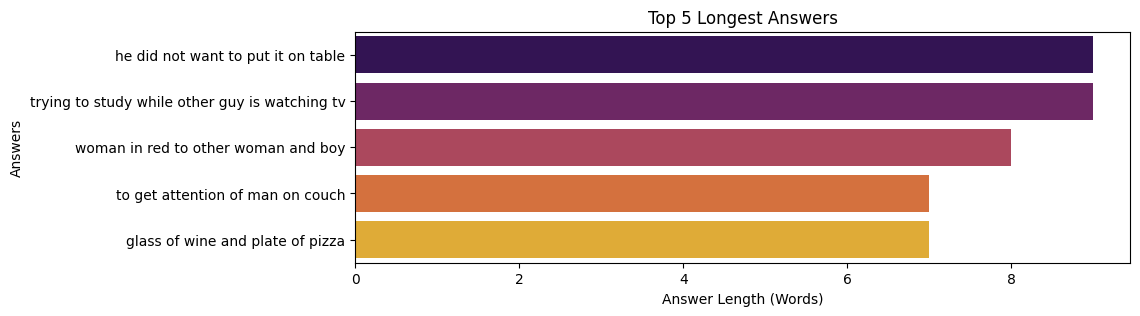

In [ ]:
# Top 5 Longest Answers

# Calculate answer lengths
answer_lengths = [len(ans.split()) for ans in answer_preprocessed]

# Create DataFrame
answer_length_df = pd.DataFrame({'answer': answer_preprocessed, 'length': answer_lengths})

# Get top 5 longest answers
longest_answers = answer_length_df.sort_values(by="length", ascending=False).head(5)

# Print results
for idx, row in longest_answers.iterrows():
    print(f"Answer {idx+1} ({row['length']} words): {row['answer']}\n")


plt.figure(figsize=(10, 3))
sns.barplot(x=longest_answers["length"], y=longest_answers["answer"], palette="inferno")
plt.title("Top 5 Longest Answers")
plt.xlabel("Answer Length (Words)")
plt.ylabel("Answers")
plt.show()


In [ ]:
# Create list of Character count, Word count, and unique words of answers
char_count_ans = []
word_count_ans = []
for a in (answer_preprocessed):
    char_count_ans.append(len(a))
    word_count_ans.append(len(a.split()))

unique_ans = set(answer_preprocessed)

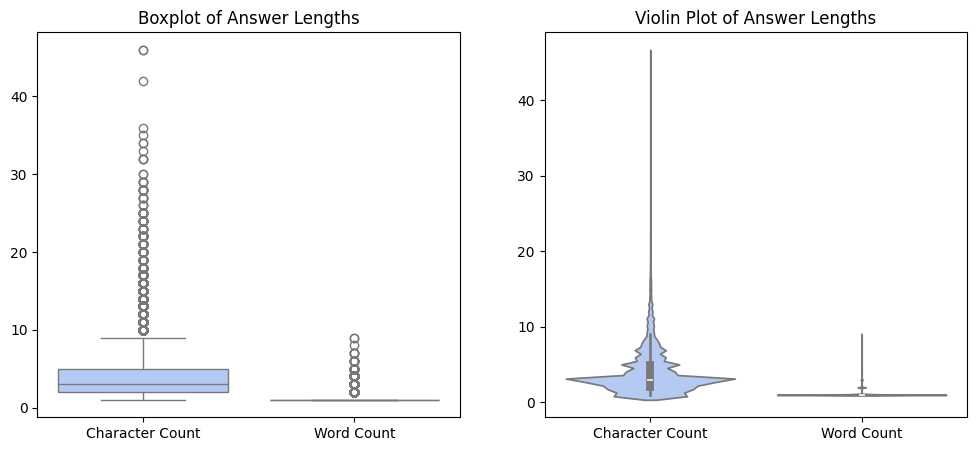

In [ ]:
plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=[char_count_ans, word_count_ans], palette="coolwarm")
plt.xticks([0, 1], ["Character Count", "Word Count"])
plt.title("Boxplot of Answer Lengths")

# Violin plot
plt.subplot(1, 2, 2)
sns.violinplot(data=[char_count_ans, word_count_ans], palette="coolwarm")
plt.xticks([0, 1], ["Character Count", "Word Count"])
plt.title("Violin Plot of Answer Lengths")

plt.show()


In [ ]:

# Percentile of word_count_ans
for i in range(0,101,10):
    print(f"{i}th percentile {np.percentile(word_count_ans,i)}")
print("-"*25)
for i in range(91,101,1):
    print(f"{i}th percentile {np.percentile(word_count_ans,i)}")

0th percentile 1.0
10th percentile 1.0
20th percentile 1.0
30th percentile 1.0
40th percentile 1.0
50th percentile 1.0
60th percentile 1.0
70th percentile 1.0
80th percentile 1.0
90th percentile 1.0
100th percentile 9.0
-------------------------
91th percentile 1.0
92th percentile 1.0
93th percentile 1.0
94th percentile 2.0
95th percentile 2.0
96th percentile 2.0
97th percentile 2.0
98th percentile 2.0
99th percentile 3.0
100th percentile 9.0


In [ ]:

print("The maximum character length of Answer:", max(char_count_ans))
print("The minimum character length of Answer:", min(char_count_ans))
print('The average character length of Answer:',int(sum(char_count_ans)/len(char_count_ans)))
print('-'*50)
print("The maximum word length of Answer:", max(word_count_ans))
print("The minimum word length of Answer:", min(word_count_ans))
print('The average word length of Answer:',int(sum(word_count_ans)/len(word_count_ans)))
print('-'*50)
print('Total number of unique Answers:',len(unique_ans))
print('Types of Answers as per given answer_type:',len(set(answer_type)))

The maximum character length of Answer: 46
The minimum character length of Answer: 1
The average character length of Answer: 3
--------------------------------------------------
The maximum word length of Answer: 9
The minimum word length of Answer: 1
The average word length of Answer: 1
--------------------------------------------------
Total number of unique Answers: 2508
Types of Answers as per given answer_type: 3


In [ ]:
# create dataframe of answer_type and its counts
answer_type_df = (abstract_train2015.groupby(['answer_type']).count()['answers']).to_frame()
answer_type_df['answer%'] = round(answer_type_df['answers'] / len(answer_type) * 100,2)
answer_type_df = answer_type_df.sort_values(by='answers',ascending=False)
answer_type_df

,answers,answer%
answer_type,,
other,26916,44.86
yes/no,24396,40.66
number,8688,14.48


In [ ]:
# create dataframe of unique answers and its counts in decending order of answer_count
count = {}
for i in answer_preprocessed:
    count[i] = count.get(i, 0) + 1

answer_df = pd.DataFrame(list(count.items()),columns=["answer","answer_count"])
answer_df["answer%"] = answer_df["answer_count"]/len(answer_preprocessed)*100
answer_df = answer_df.sort_values(by='answer_count',ascending=False)
answer_df.head(10)

,answer,answer_count,answer%
3,yes,14314,23.856667
7,no,10143,16.905000
15,2,3496,5.826667
16,1,1934,3.223333
32,red,1506,2.510000
20,3,1373,2.288333
107,white,789,1.315000
33,yellow,603,1.005000
34,blue,603,1.005000
70,4,599,0.998333


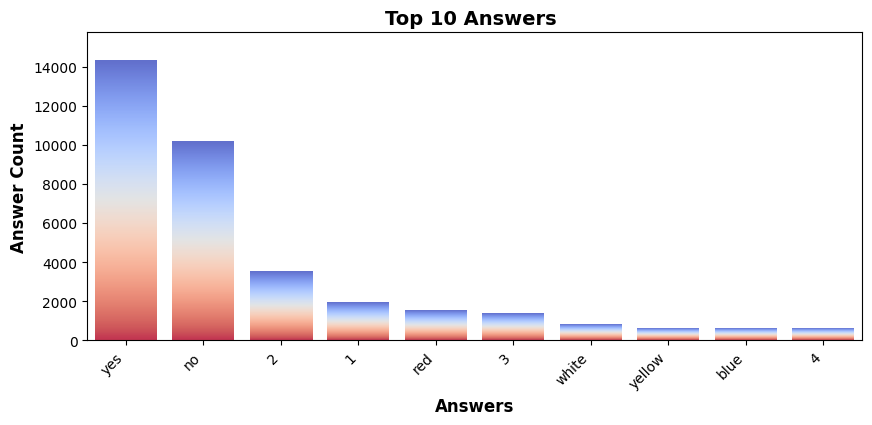

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Sample data (replace with actual DataFrame)
answers = list(answer_df['answer'])[:10]  # Take top 10 answers
counts = list(answer_df['answer_count'])[:10]

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 4))

# Define colormap (you can try 'plasma', 'coolwarm', etc.)
cmap = plt.get_cmap("coolwarm")

# Normalize count values for color mapping
norm = plt.Normalize(min(counts), max(counts))

# Create gradient bars
for i, (answer, count) in enumerate(zip(answers, counts)):
    # Create a gradient from light to dark
    gradient = np.linspace(0, 1, 100).reshape(-1, 1)  # Gradient array
    gradient_color = cmap(norm(count))  # Get color based on count

    # Display the gradient as a bar
    ax.imshow(gradient, extent=[i - 0.4, i + 0.4, 0, count], aspect="auto",
              cmap=cmap, alpha=0.8, interpolation="bicubic")

# Set axis limits
ax.set_xlim(-0.5, len(answers) - 0.5)
ax.set_ylim(0, max(counts) * 1.1)

# Labels and Titles
plt.title('Top 10 Answers ', fontsize=14, fontweight='bold')
plt.xlabel('Answers', fontsize=12, fontweight='bold')
plt.ylabel('Answer Count', fontsize=12, fontweight='bold')

# Rotate x-ticks for readability
plt.xticks(range(len(answers)), answers, rotation=45, ha='right', fontsize=10)

# Show plot
plt.show()


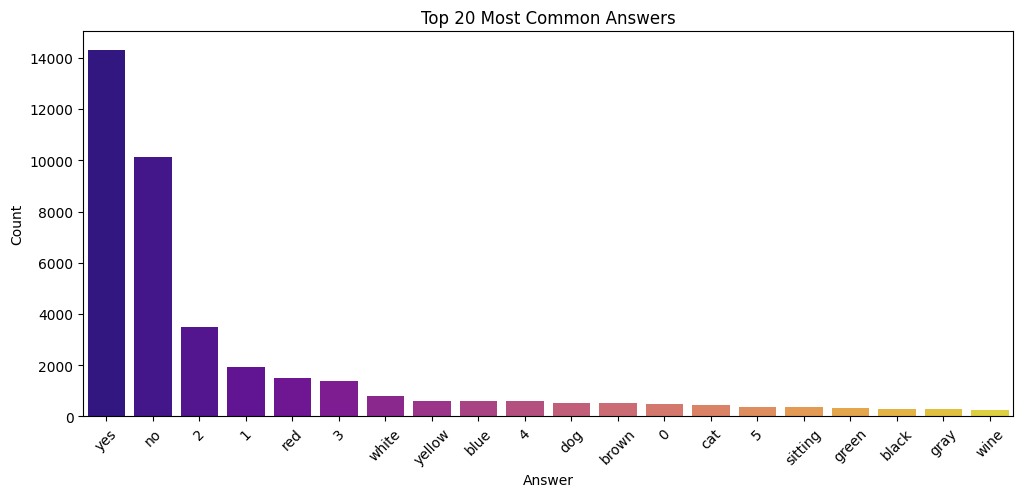

In [ ]:
plt.figure(figsize=(12, 5))
answer_counts = pd.Series(answer_preprocessed).value_counts().head(20)  # Top 20 Answers
sns.barplot(x=answer_counts.index, y=answer_counts.values, palette="plasma")
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Answers")
plt.xlabel("Answer")
plt.ylabel("Count")
plt.show()


In [ ]:
print(f"Top 1000 answers coverd {round(sum(list(answer_df['answer%'][:1000])),2)}% of datapoints")
print(f"Top 2000 answers coverd {round(sum(list(answer_df['answer%'][:2000])),2)}% of datapoints")
print(f"Top 3000 answers coverd {round(sum(list(answer_df['answer%'][:3000])),2)}% of datapoints")

Top 1000 answers coverd 97.46% of datapoints
Top 2000 answers coverd 99.15% of datapoints
Top 3000 answers coverd 100.0% of datapoints


In [ ]:
# Questions & Answers who have answer length >= 10
for i,a in enumerate(answer_preprocessed):
    if len(a.split()) >= 10:
        print('Que:',question_preprocessed[i])
        print('Ans:',a)
        print('Length of Ans:',len(a.split()))
        print("-"*50)

# EDA- QUESTION AND ANSWER

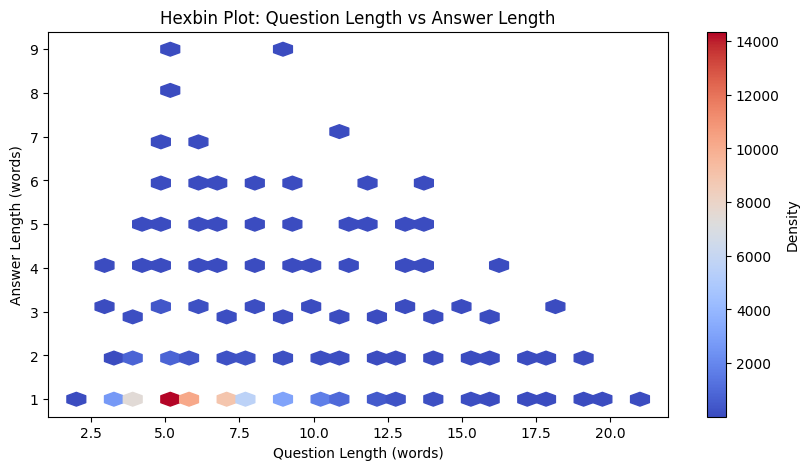

In [ ]:
# Ensure question_lengths and answer_lengths are defined
question_lengths = [len(q.split()) for q in question_preprocessed]
answer_lengths = [len(a.split()) for a in answer_preprocessed]

# Hexbin plot
plt.figure(figsize=(10, 5))
plt.hexbin(question_lengths, answer_lengths, gridsize=30, cmap="coolwarm", mincnt=1)
plt.colorbar(label="Density")
plt.title("Hexbin Plot: Question Length vs Answer Length")
plt.xlabel("Question Length (words)")
plt.ylabel("Answer Length (words)")
plt.show()


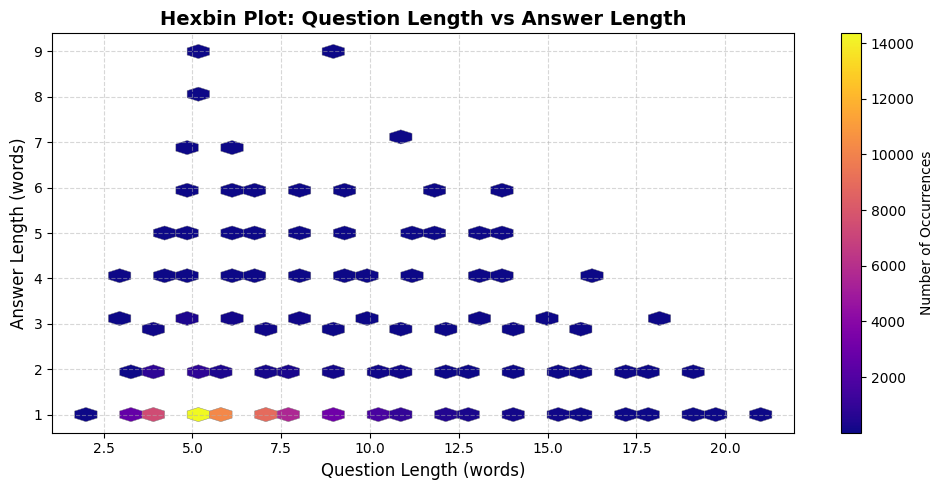

In [ ]:
import matplotlib.pyplot as plt

# Ensure you have these lists prepared
question_lengths = [len(q.split()) for q in question_preprocessed]
answer_lengths = [len(a.split()) for a in answer_preprocessed]

# Hexbin plot with improved aesthetics
plt.figure(figsize=(10, 5))
hb = plt.hexbin(
    question_lengths,
    answer_lengths,
    gridsize=30,
    cmap="plasma",  # alternative: "", "magma", "cividis", "viridis"
    mincnt=1,
    edgecolors="grey",
    linewidths=0.3
)
plt.colorbar(hb, label="Number of Occurrences")
plt.title("Hexbin Plot: Question Length vs Answer Length", fontsize=14, weight="bold")
plt.xlabel("Question Length (words)", fontsize=12)
plt.ylabel("Answer Length (words)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


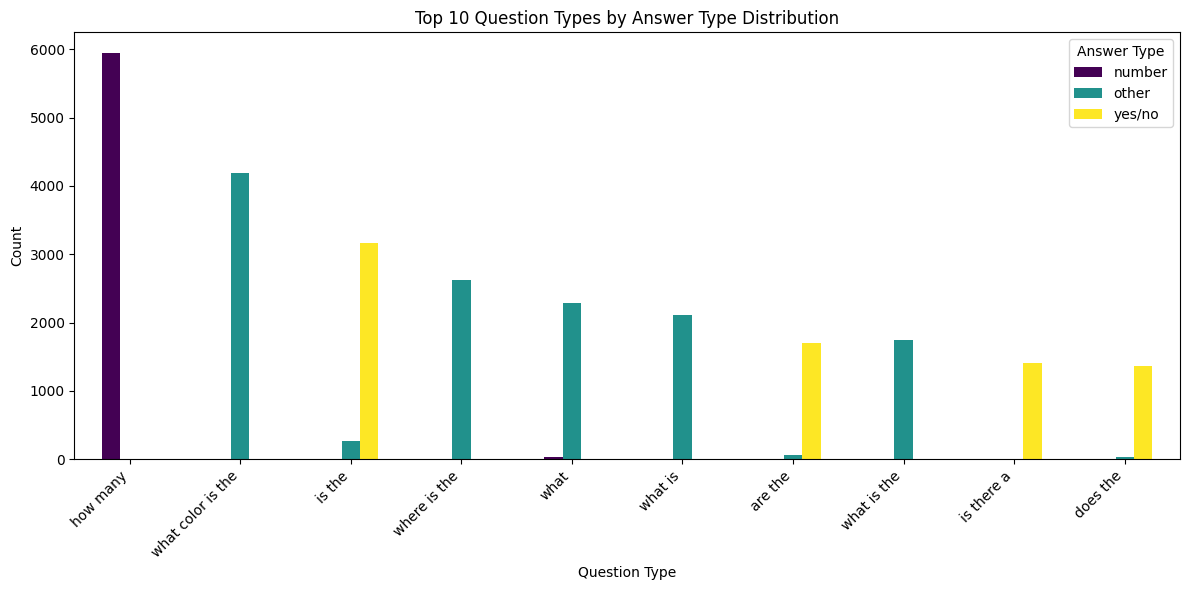

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crosstab of frequencies
cross_tab = pd.crosstab(pd.Series(question_type), pd.Series(answer_type))

# Select Top 10 question types
top_q_types = cross_tab.sum(axis=1).nlargest(10).index
filtered = cross_tab.loc[top_q_types]

# Plot as grouped bar chart
filtered.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='viridis')
plt.title("Top 10 Question Types by Answer Type Distribution")
plt.xlabel("Question Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Answer Type')
plt.tight_layout()
plt.show()


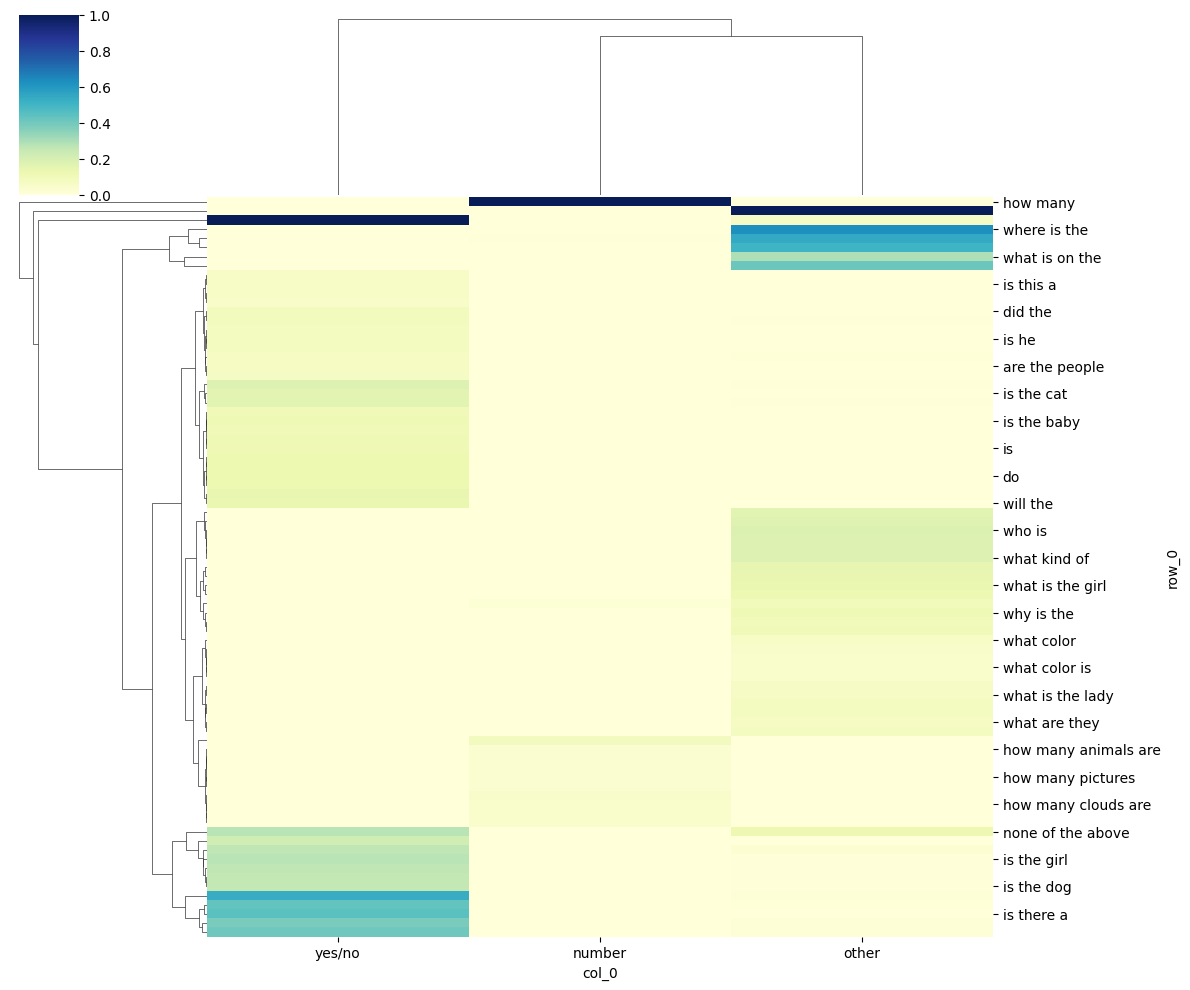

In [ ]:
sns.clustermap(cross_tab, cmap='YlGnBu', figsize=(12, 10), standard_scale=1)

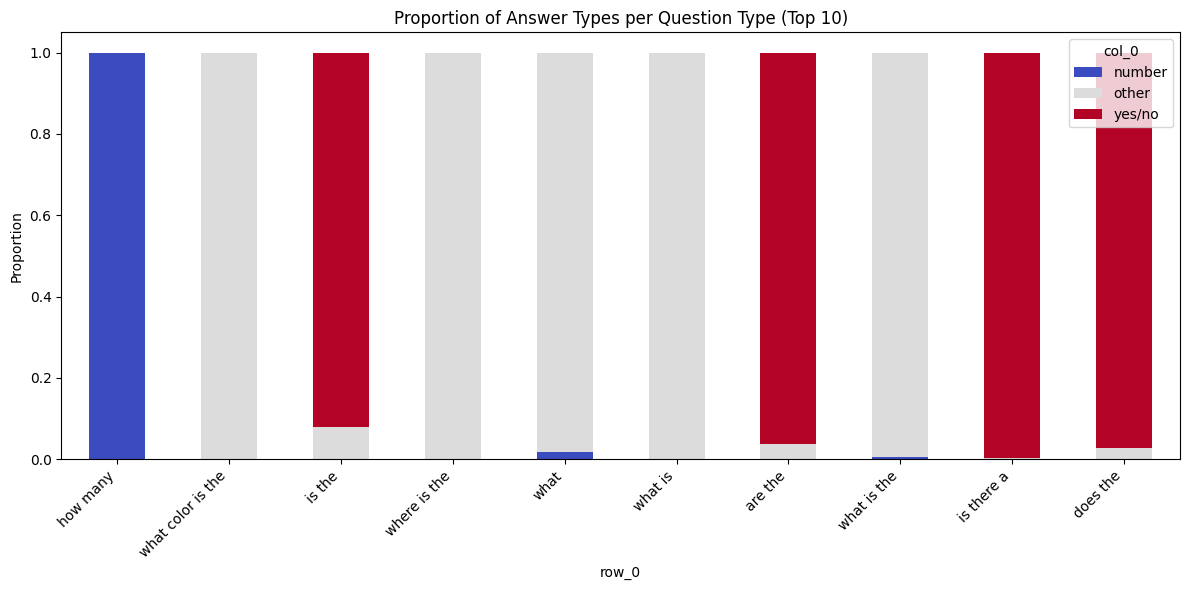

In [ ]:
normalized = cross_tab.div(cross_tab.sum(axis=1), axis=0)
normalized.loc[top_q_types].plot(kind='bar', stacked=True, figsize=(12,6), colormap='coolwarm')
plt.title("Proportion of Answer Types per Question Type (Top 10)")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def que_ans_analysis2(word_1, word_2, palette="coolwarm"):
    word_1_2_df = question_answer_df[(question_answer_df[0] == word_1) & (question_answer_df[1] == word_2)]
    word_1_2_count = word_1_2_df.groupby(['answer']).size().reset_index(name='count')
    word_1_2_count = word_1_2_count.sort_values(by='count', ascending=False).head(20)

    # Define color gradient using a chosen palette
    colors = sns.color_palette(palette, len(word_1_2_count))

    plt.figure(figsize=(20, 6))
    plt.bar(word_1_2_count["answer"], word_1_2_count["count"], color=colors, edgecolor='black')

    # Titles and labels
    plt.title(f'Count of Top 20 Answers for "{word_1} {word_2}" Questions', fontsize=14, fontweight='bold', color='darkblue')
    plt.xlabel('Top 20 Answers', fontsize=12, fontweight='bold', color='darkred')
    plt.ylabel('Count', fontsize=12, fontweight='bold', color='darkgreen')

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right', fontsize=10)

    plt.show()

# Example usage with different color palettes
que_ans_analysis2("is", "the", palette="flare")   # Try "magma", "viridis", "cubehelix", etc.



NameError: name 'question_answer_df' is not defined

In [ ]:
que_ans_analysis2("what","is", "coolwarm")


In [ ]:
que_ans_analysis2("how","many", "viridis")


In [ ]:
que_ans_analysis2("what","color","plasma")



In [ ]:
que_ans_analysis2("where","is","cividis")


# EDA — QUESTION_TYPE



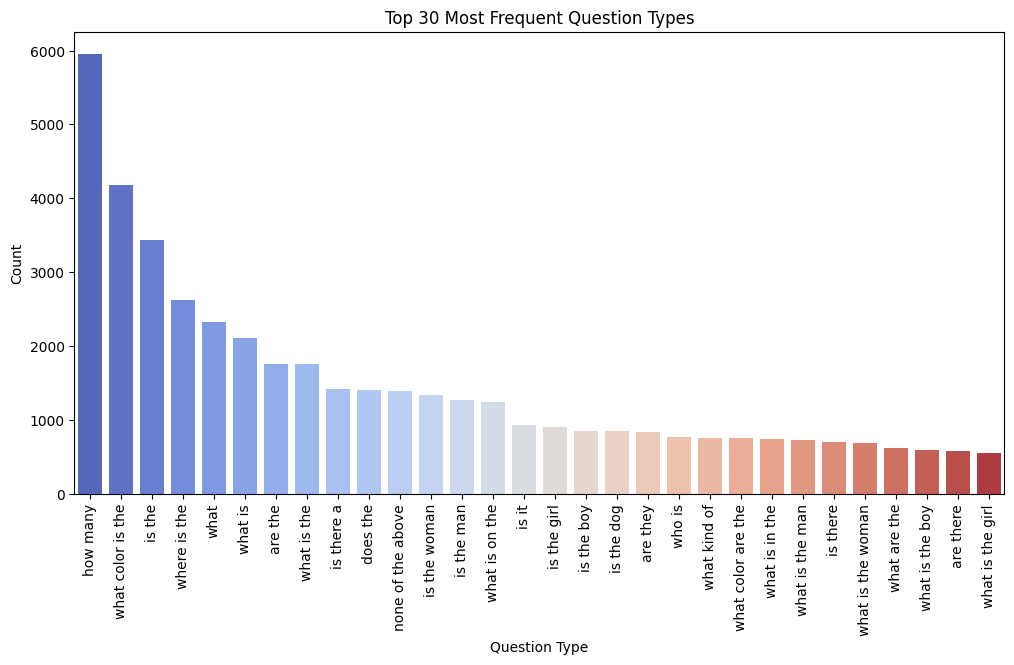

In [ ]:
# Get the top 30 most frequent question types
top_ques_types = pd.Series(question_type).value_counts().head(30)

# Plot the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=top_ques_types.index, y=top_ques_types.values, palette="coolwarm")

# Formatting
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.title("Top 30 Most Frequent Question Types")
plt.xlabel("Question Type")
plt.ylabel("Count")
plt.show()


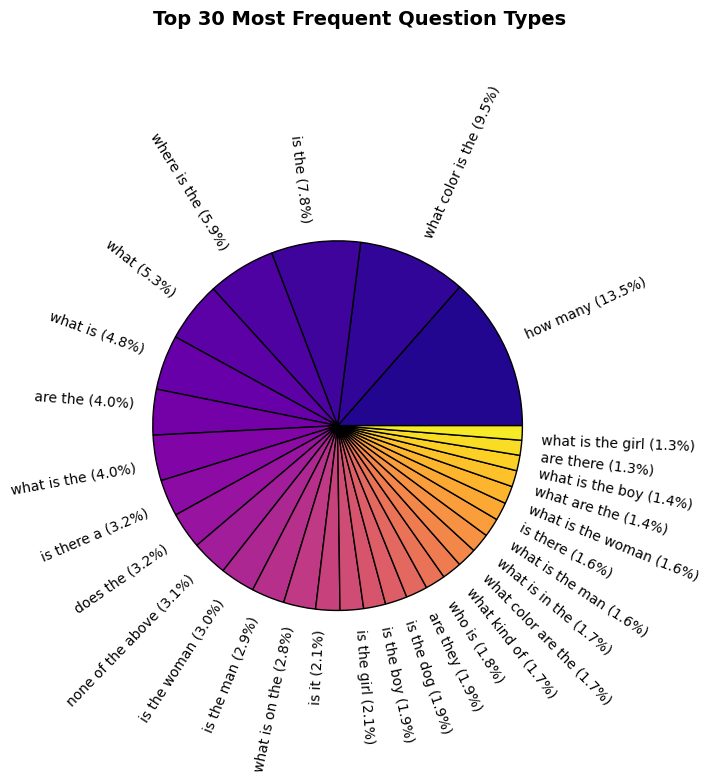

In [ ]:
plt.figure(figsize=(10, 6))

# Format labels to include both question type & percentage
labels = [f"{ques} ({perc:.1f}%)" for ques, perc in zip(top_ques_types.index, (top_ques_types / top_ques_types.sum()) * 100)]

plt.pie(
    top_ques_types,
    labels=labels,  # Labels with percentage
    colors=sns.color_palette("plasma", len(top_ques_types)),
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},  # Adding borders for clarity
    rotatelabels=True  # Rotate labels to align with slices
)

plt.text(-1, 2.2, "Top 30 Most Frequent Question Types",
         fontsize=14, fontweight='bold', ha='left', va='center')
plt.show()


# EDA — ANSWER_TYPE



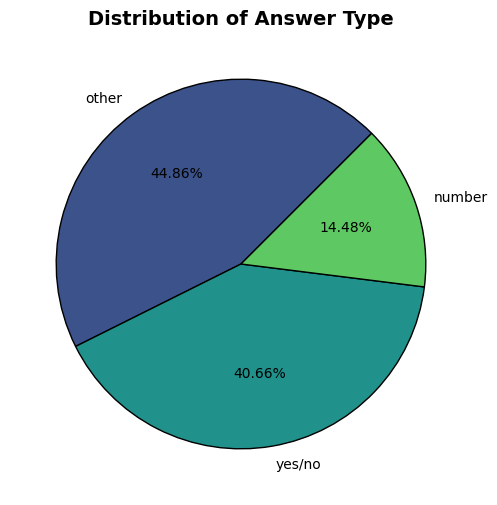

In [ ]:
# plot pie chart of dataframe of answer_type and its counts
import matplotlib.pyplot as plt
import seaborn as sns

# Generate colors using seaborn color palette
colors = sns.color_palette("viridis", len(answer_type_df))

# Plot pie chart
plt.figure(figsize=(8, 6))
plt.pie(list(answer_type_df['answer%']), labels=list(answer_type_df.index),
        autopct='%1.2f%%', startangle=45, colors=colors, wedgeprops={'edgecolor': 'black'})

plt.title('Distribution of Answer Type', fontsize=14, fontweight='bold')
plt.show()


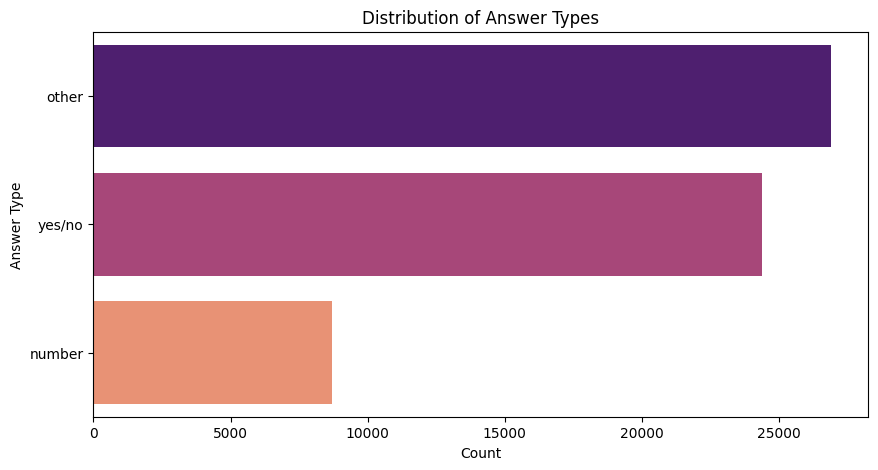

In [ ]:

# Plot answer type distribution
plt.figure(figsize=(10, 5))
sns.countplot(y=df["answer_type"], order=df["answer_type"].value_counts().index, palette="magma")
plt.title("Distribution of Answer Types")
plt.xlabel("Count")
plt.ylabel("Answer Type")
plt.show()





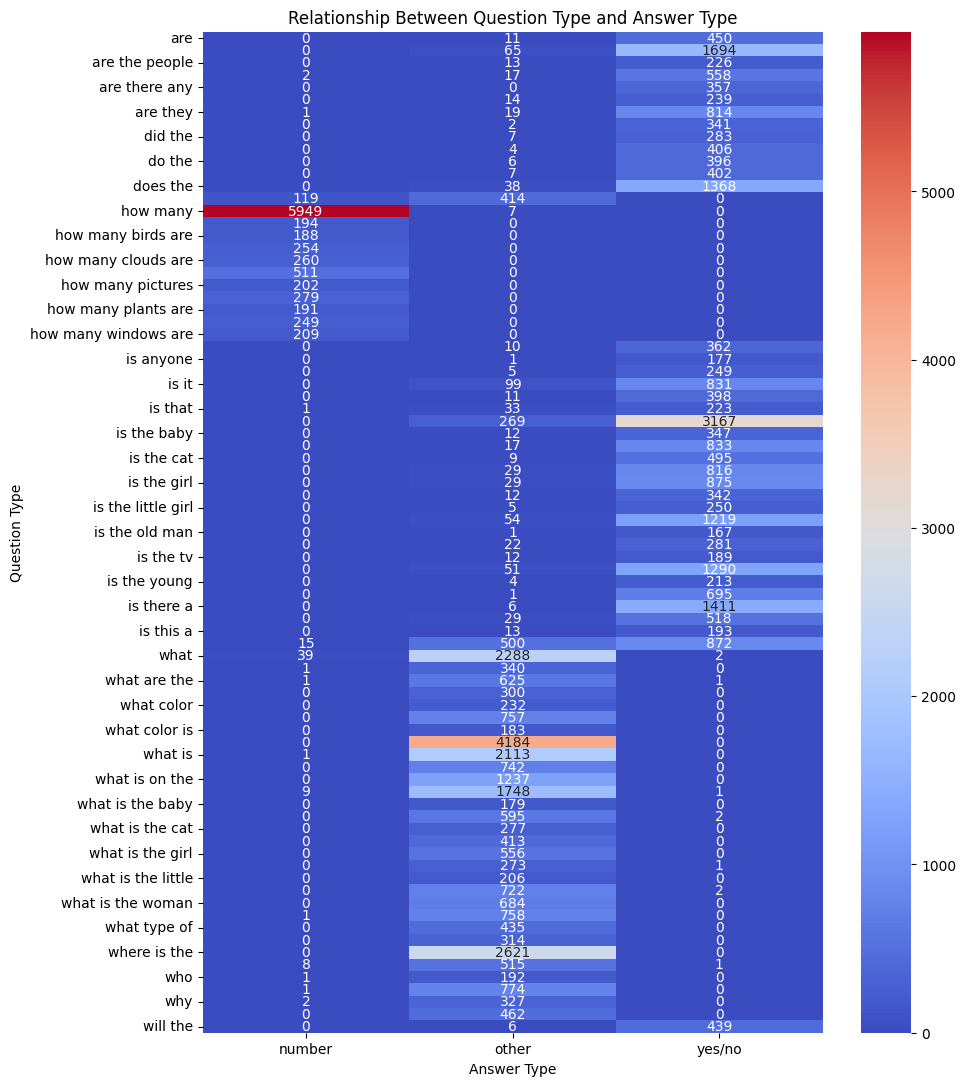

In [ ]:
plt.figure(figsize=(10, 13))
sns.heatmap(pd.crosstab(pd.Series(question_type), pd.Series(answer_type)), cmap="coolwarm", annot=True, fmt="d")
plt.title("Relationship Between Question Type and Answer Type")
plt.xlabel("Answer Type")
plt.ylabel("Question Type")
plt.show()
